# Afriskaut Dynasty Scouting League 2024 – Getting Started

This notebook walks through loading, exploring, and visualising Afriskaut open event data.

**Requirements:** `pandas`, `matplotlib`
```bash
pip install pandas matplotlib
```

**Before you begin:** Unzip `Datasets.zip` so the `Datasets/` folder is in the same directory as this notebook.

In [8]:
import os
import pandas as pd
from afriskaut_utils import load_match, load_events, load_all_events, build_plot_data, plot_events

## 1. List available matches

In [9]:
datasets_path = "Datasets"
match_ids = sorted(os.listdir(datasets_path))

print(f"Found {len(match_ids)} matches")
print(match_ids[:10])

Found 137 matches
['65ecbe0aa6760f66b4f063e1', '65fc400c043ab4ea21f879ac', '65fc8000043ab4ea21f87d44', '6604866c2e4dbcfcb88f1908', '6605587a2e4dbcfcb88f2381', '6605bd89307e1fbe0c4c85c9', '6606b2e0aecc56823e307e7f', '660d3efdb0dd27e265dc1e2d', '660e3eebf1cddbb67c7d0ff0', '660f99dc0b4eb3501879a416']


## 2. Load a single match

In [10]:
# Change this to any MatchID from the list above
match_id  = '65fc400c043ab4ea21f879ac' #Example Match ID, change to any other from the list above
match_dir = os.path.join(datasets_path, match_id)

match  = load_match(match_dir)
events = load_events(match_dir)

print(f"Match  : {match['home_team_string']} vs {match['away_team_string']}")
print(f"Score  : {match['home_goals']} – {match['away_goals']}")
print(f"Date   : {match.get('date', 'N/A')}")
print(f"Events : {len(events)}")

Match  : Immaculate FC vs Future Bright FA
Score  : 4 – 1
Date   : 21/03/2024
Events : 909


## 3. Explore event types

In [11]:
# Column names - adjust these if your specific JSON schema differs
event_name_col = "event_name"
event_type_col = "event_type"
event_outcome_col = "event_outcome" 

# Verify all columns exist before processing
required_cols = [event_type_col, event_name_col, event_outcome_col]
if all(col in events.columns for col in required_cols):
    print(f"Summary of Match Events (Type > Name > Outcome):")
    print("-" * 75)
    
    # Grouping by all three dimensions to see the breakdown of results
    summary = (
        events.groupby([event_type_col, event_name_col, event_outcome_col])
        .size()
        .reset_index(name='counts')
        .sort_values(by=[event_type_col, 'counts'], ascending=[True, False])
    )
    
    # Using to_string(index=False) for a clean, table-like output
    print(summary.to_string(index=False))
else:
    missing = [col for col in required_cols if col not in events.columns]
    print(f"Error: Could not find columns: {missing}")
    print(f"Available columns in your data: {list(events.columns)}")

Summary of Match Events (Type > Name > Outcome):
---------------------------------------------------------------------------
       event_type   event_name            event_outcome  counts
      AERIAL_DUEL         DUEL             UNSUCCESSFUL      10
      AERIAL_DUEL         DUEL               SUCCESSFUL       3
 BALL_PROGRESSION   POSSESSION                                1
            BLOCK  DEF_ACTIONS                                5
            CATCH   GK_ACTIONS                   SIMPLE      16
            CATCH   GK_ACTIONS                  COMPLEX       1
    CLAIMED_CROSS   GK_ACTIONS                                3
        CLEARANCE  DEF_ACTIONS           UNDER_PRESSURE      32
          DRIBBLE   POSSESSION               SUCCESSFUL       6
          DRIBBLE   POSSESSION             UNSUCCESSFUL       1
            ERROR  DEF_ACTIONS                                1
          FLOATED        CROSS               SUCCESSFUL       1
             FOUL  DEF_ACTIONS             

## 4. Plot events on the pitch

Set `target_event` to any event type from the output above.  
Consult `Afriskaut Event Map - 2024.pdf` for the full list of event definitions.

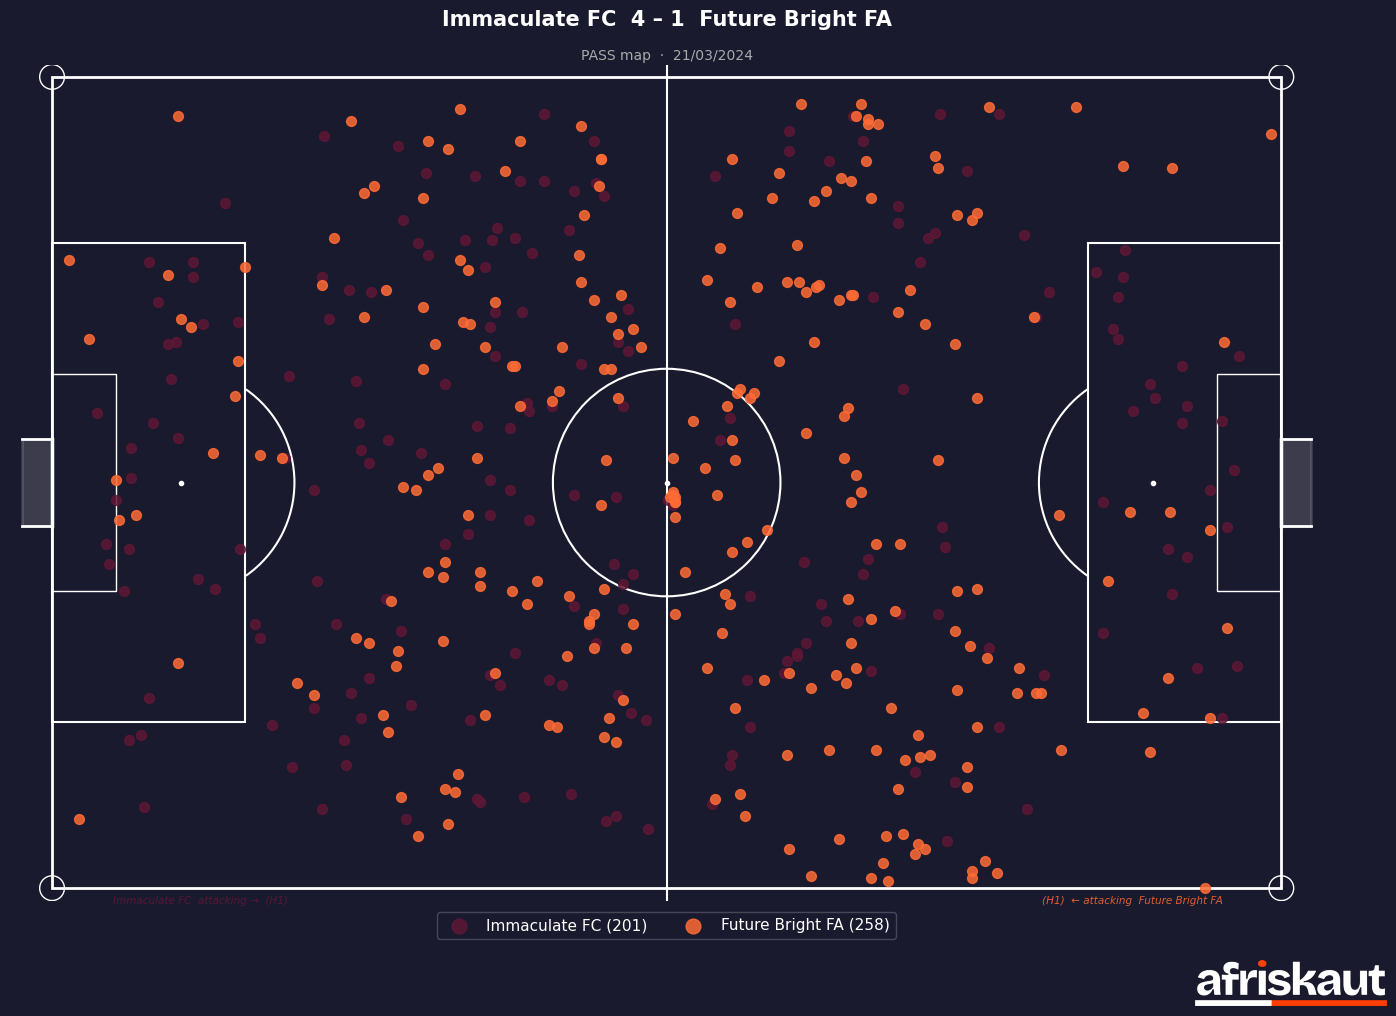

Plotted 459 'PASS' events  (201 home · 258 away)


In [ ]:
target_event = "PASS"  # change to any event name from the list above

# sanity check — print available types if nothing matches
filtered = events[events["event_name"] == target_event]
if filtered.empty:
    print(f"No events found for '{target_event}'. Available types:")
    print(events["event_name"].value_counts().to_string())
else:
    home_events, away_events = build_plot_data(filtered, match)
    plot_events(match, home_events, away_events, event_label=target_event)

## 5. Load the full dataset

To work across all matches at once:

In [14]:
all_events = load_all_events(datasets_path)

print(f"Total events : {len(all_events)}")
print(f"Matches      : {all_events['match_id'].nunique()}")
all_events.head(3)

Total events : 84214
Matches      : 136


,_id,match_id,competition_id,season_id,team_id,player_id,isHome,event_outcome,event_name,event_type,...,marker_y,marker_size,frame_rate,frame_width,frame_height,timestamp,updatedAt,event_context,recipient_player_id,createdAt
0,67a1fc92ab4513cf9c723084,65ecbe0aa6760f66b4f063e1,658a93a1dca4b280f2be6485,658bf4aedad0e634df942e48,65e5d94e44928ed5fa504fe1,65e5e02f44928ed5fa5050c6,1,SUCCESSFUL,CORNER,HIGH_CROSS,...,0.0,MEDIUM,0.0,0.0,0.0,,2025-03-19T15:24:26.253000,NaN,NaN,NaN
1,67a1fc92ab4513cf9c72300d,65ecbe0aa6760f66b4f063e1,658a93a1dca4b280f2be6485,658bf4aedad0e634df942e48,65e5d94e44928ed5fa504fe1,65f08260e8c7a22179b8830d,1,SUCCESSFUL,CORNER,HIGH_CROSS,...,0.0,MEDIUM,0.0,0.0,0.0,,2025-03-19T15:24:26.325000,,NaN,NaN
2,67a1fc92ab4513cf9c72308c,65ecbe0aa6760f66b4f063e1,658a93a1dca4b280f2be6485,658bf4aedad0e634df942e48,65e5d94e44928ed5fa504fe1,65e5dd8a44928ed5fa505087,1,SUCCESSFUL,CORNER,HIGH_CROSS,...,0.0,MEDIUM,0.0,0.0,0.0,,2025-03-19T15:24:26.040000,NaN,NaN,NaN


---

## Reference

| File | Purpose |
|------|---------|
| `Afriskaut Event Map - 2024.pdf` | Full event type definitions and tagging rules |
| `Pitch Coordinates For Afriskaut Event Data.pdf` | Visual reference for the 497 × 328 coordinate system |
| `summary.csv` | Event counts per match for quick overview |
| `afriskaut_utils.py` | Utility functions used by this notebook |

Built something with this data? Tag **Afriskaut** or reach out at [tayo@afriskaut.com](mailto:tayo@afriskaut.com)